In [20]:
# import modules
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from libpysal.weights import KNN
from esda import Moran
import numpy as np

# load data

pizza = gpd.read_file("Data/pizza_location_name_cuisine.gpkg")
crashes = pd.read_csv("Data/CrashStatisticsFranklinCounty.csv")

# get the boundaries of Franklin county
franklincounty = gpd.read_file("Data/Municipal_Boundaries.shp")

# use same CRS
pizza = pizza.to_crs(franklincounty.crs)
# filter by location
pizza_within_franklin = pizza[pizza.within(franklincounty.geometry.iloc[0])]


print(pizza.within(franklincounty.union_all()).value_counts())

# drop missing coords
crashes = crashes.dropna(subset=["Latitude", "Longitude"])

# create GeoDataFrames
gdf_crashes = gpd.GeoDataFrame(
    crashes,
    geometry=gpd.points_from_xy(crashes["Longitude"], crashes["Latitude"]),
    crs="EPSG:4326"
)
gdf_pizza = pizza_within_franklin.copy()

# ensure CRS match
if gdf_pizza.crs.to_epsg() != 4326:
    gdf_pizza = gdf_pizza.to_crs(epsg=4326)


# compute distance to nearest fastfood outlet
# for computational efficiency, project to meters

gdf_crashes_m = gdf_crashes.to_crs(epsg=3857)
gdf_pizza_m = gdf_pizza.to_crs(epsg=3857)

# compute nearest fastfood distance for each crash
nearest_dist = []
for crash_point in gdf_crashes_m.geometry:
    dist = gdf_pizza_m.distance(crash_point).min()
    nearest_dist.append(dist)

gdf_crashes_m["dist_to_pizza_m"] = nearest_dist
# get rid of nans
print(gdf_crashes_m["dist_to_pizza_m"].isna().sum())
gdf_crashes_m = gdf_crashes_m.dropna(subset=["dist_to_pizza_m"])


# build spatial weights (neighbors)
# Moran's I
# variable of interest: inverse distance (closer = higher value)
gdf_crashes_m["pizza_proximity"] = 1 / (gdf_crashes_m["dist_to_pizza_m"] + 1)
gdf_crashes_m = gdf_crashes_m.dropna(subset=["pizza_proximity"])

# use KNN = 8 nearest crashes as neighborhood
w = KNN.from_dataframe(gdf_crashes_m, k=8)
w.transform = 'R'

moran = Moran(gdf_crashes_m["pizza_proximity"], w)


print("Moran's I statistic:", moran.I)
print("Expected I (under null):", moran.EI)
print("Z-score:", moran.z)
print("p-value:", moran.p_sim)

if moran.p_sim < 0.05:
    print("Significant spatial autocorrelation detected.")
else:
    print("No significant spatial autocorrelation detected.")


C:\Users\boie.2\AppData\Local\Temp\ipykernel_38264\2290738802.py:12: DtypeWarning:

Columns (23,31) have mixed types. Specify dtype option on import or set low_memory=False.

C:\Users\boie.2\AppData\Local\Temp\ipykernel_38264\2290738802.py:22: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



False    1499
True      209
Name: count, dtype: int64
0


c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 29 disconnected components.



Moran's I statistic: 0.3841553724450329
Expected I (under null): -8.70852564660803e-06
Z-score: [ 0.07010022 -0.08949399 -0.0913769  ...  0.26089778 -0.01266837
 -0.03167727]
p-value: 0.001
Significant spatial autocorrelation detected.


In [21]:
franklincounty

,NAME,NAME2,NAME3,MUNITYP,GlobalID,Shape_STAr,Shape_STLe,geometry
0,Bexley,Bexley,BEXLEY CITY,City,{124C6BC0-28CA-4A96-BC46-D9E23220B865},6.805496e+07,3.954397e+04,"POLYGON ((1848913.2 722274.6, 1848892.641 7219..."
1,Blendon,Blendon Township,BLENDON TWP,Township,{178C51E3-EA1E-4528-A590-1EEF7BBC618D},1.147359e+08,2.383176e+05,"MULTIPOLYGON (((1847101.882 750164.817, 184710..."
2,Brice,Brice,BRICE CORP,Village,{11803FE5-6106-49B6-A684-15D5AC171275},2.503592e+06,1.165081e+04,"POLYGON ((1875467.55 699926.87, 1875458.238 69..."
3,Brown,Brown Township,BROWN TWP,Township,{6E3D9D8A-132D-43D0-BBB2-1123F1B3DCB5},5.343980e+08,2.194871e+05,"MULTIPOLYGON (((1773051.735 741920.743, 177322..."
4,Canal Winchester,Canal Winchester,CANAL WINCHESTER CORP,City,{BB3F961F-1A8C-4858-9064-BF172110E4DB},1.698667e+08,8.998651e+04,"MULTIPOLYGON (((1877774.187 663792.003, 187777..."
5,Clinton,Clinton Township,CLINTON TWP,Township,{C0F48E80-18A3-43E9-B9FE-0FCF8D72DAB1},3.845585e+07,1.428868e+05,"MULTIPOLYGON (((1839545.759 723811.705, 183954..."
6,Columbus,Columbus,COLUMBUS CITY,City,{33F3B448-0DF6-48C8-90AF-6C322687961E},6.245908e+09,3.196491e+06,"MULTIPOLYGON (((1809601.001 748642.035, 180973..."
7,Commercial Point,Commercial Point,VILLAGE OF COMMERCIAL POINT,Village,{1E927081-8B5E-43D8-BEB6-6C4E6995E2D0},1.982325e+05,3.254893e+03,"POLYGON ((1824146.021 657546.413, 1824158.8 65..."
8,Dublin,Dublin,DUBLIN CITY,City,{D415B49B-6508-4D47-B05F-4EAA386DFEF7},5.978980e+08,2.537424e+05,"POLYGON ((1803708.629 779700.618, 1803682.785 ..."
9,Franklin,Franklin Township,FRANKLIN TWP,Township,{265EAD03-6831-4871-9C65-73A61D3BA59E},1.844829e+08,4.823538e+05,"MULTIPOLYGON (((1821690.592 694563.402, 182157..."


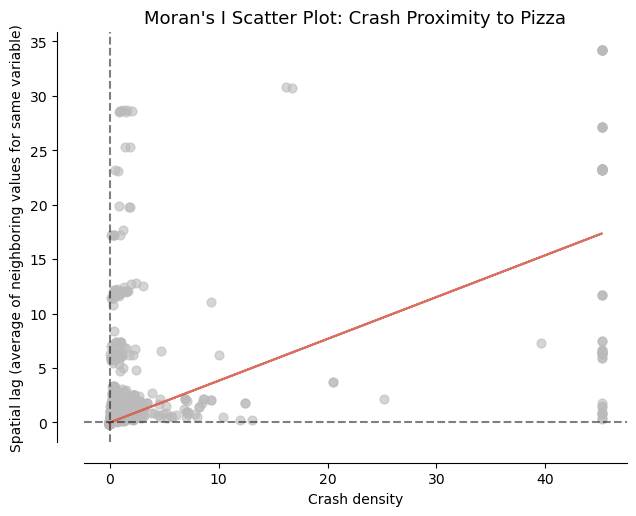

c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 9067 disconnected components.

c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 690 disconnected components.

c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 99 disconnected components.

c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 29 disconnected components.

c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 11 disconnected components.



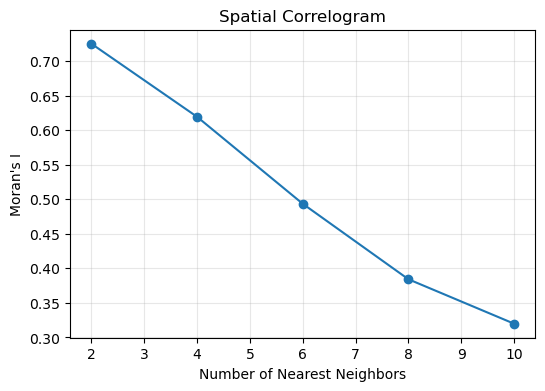

In [22]:
# Moran scatter plot (corrected)
import matplotlib.pyplot as plt
from esda.moran import Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_title("Moran's I Scatter Plot: Crash Proximity to Pizza", fontsize=13)
ax.set_xlabel("Crash density")
ax.set_ylabel("Spatial lag (average of neighboring values for same variable)")
plt.show()

# Moran correlogram (spatial autocorrelation vs distance)
distances = [2, 4, 6, 8, 10]
morans = []
for k in distances:
    w_k = KNN.from_dataframe(gdf_crashes_m, k=k)
    w_k.transform = 'R'
    moran_k = Moran(gdf_crashes_m["pizza_proximity"], w_k)
    morans.append(moran_k.I)

plt.figure(figsize=(6,4))
plt.plot(distances, morans, marker='o')
plt.title("Spatial Correlogram")
plt.xlabel("Number of Nearest Neighbors")
plt.ylabel("Moran's I")
plt.grid(True, alpha=0.3)
plt.show()


In [23]:
# load modules
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap


# Load crash and fastfood data
crashes = pd.read_csv("Data/CrashStatisticsFranklinCounty.csv").dropna(subset=["Latitude", "Longitude"])
pizza = gpd.read_file("Data/pizza_location_name_cuisine.gpkg")

# Create GeoDataFrames
gdf_crashes = gpd.GeoDataFrame(
    crashes, geometry=gpd.points_from_xy(crashes["Longitude"], crashes["Latitude"]), crs="EPSG:4326"
)
gdf_pizza = pizza.to_crs(epsg=4326)

# Project to a local metric coordinate system (meters)
gdf_crashes_m = gdf_crashes.to_crs(epsg=3857)
gdf_pizza_m = gdf_pizza.to_crs(epsg=3857)

# create hexagonal grid to aggregate crashes
xmin, ymin, xmax, ymax = gdf_crashes_m.total_bounds
cell_size = 500  # 500 m grid

cols = np.arange(xmin, xmax + cell_size, cell_size)
rows = np.arange(ymin, ymax + cell_size, cell_size)

polygons = []
for x in cols:
    for y in rows:
        polygons.append(Point(x, y).buffer(cell_size / 2))

grid = gpd.GeoDataFrame(geometry=polygons, crs=gdf_crashes_m.crs)

# Count crashes in each grid cell
grid["crash_count"] = grid.geometry.apply(
    lambda g: gdf_crashes_m.within(g).sum()
)

# Count fastfood locations in each grid cell
grid["pizza_count"] = grid.geometry.apply(
    lambda g: gdf_pizza_m.within(g).sum()
)

# Filter cells with data (filter out low or zero counts)
grid = grid[(grid["crash_count"] > 0) & (grid["pizza_count"] > 0)].copy()


# variables for GWR
# Dependent variable (crash density)
y = grid["crash_count"].values.reshape((-1, 1))

# Independent variable
X = grid[["pizza_count"]].values  # can add more columns if available

# Coordinates
u = grid.geometry.centroid.x.values
v = grid.geometry.centroid.y.values
coords = np.column_stack((u, v))


# Select bandwidth and fit model
bw = Sel_BW(coords, y, X).search(bw_min=3)
print("Optimal bandwidth:", bw)

# Fit the GWR model
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())


# add results to GeoDataFrame

grid["beta_pizza"] = gwr_results.params[:, 1]
grid["beta_intercept"] = gwr_results.params[:, 0]
grid["local_r2"] = gwr_results.localR2



C:\Users\boie.2\AppData\Local\Temp\ipykernel_38264\4087959714.py:8: DtypeWarning:

Columns (23,31) have mixed types. Specify dtype option on import or set low_memory=False.



Optimal bandwidth: 129.0
Model type                                                         Gaussian
Number of observations:                                                 134
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                         318108.051
Log-likelihood:                                                    -710.882
AIC:                                                               1425.765
AICc:                                                              1427.949
BIC:                                                             317461.536
R2:                                                                   0.001
Adj. R2:                                                             -0.007

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---

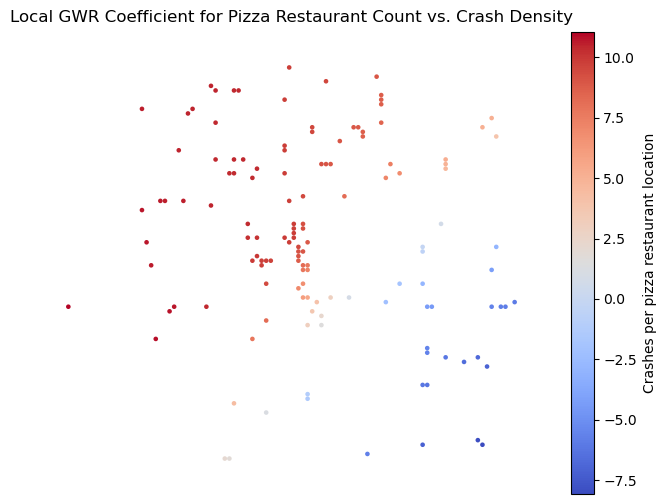

In [24]:
# plot local coefficients

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot = grid.plot(column="beta_pizza", cmap="coolwarm", legend=True, ax=ax)
cbar = plot.get_figure().axes[-1]

cbar.set_ylabel("Crashes per pizza restaurant location")
ax.set_title("Local GWR Coefficient for Pizza Restaurant Count vs. Crash Density")
ax.axis("off")
plt.show()

In [26]:
# add the map in the plot
import plotly.express as px

# convert grid to WGS84

grid_wgs84 = grid.to_crs(epsg=4326)

# get coordinates
grid_wgs84["lon"] = grid_wgs84.geometry.centroid.x
grid_wgs84["lat"] = grid_wgs84.geometry.centroid.y

# new plot
fig = px.scatter_mapbox(
    grid_wgs84,
    lat="lat",
    lon="lon",
    color="beta_pizza",
    color_continuous_scale=list(reversed(px.colors.diverging.RdBu)),
    size_max=15,
    zoom=10,
    mapbox_style="carto-positron",
    title="Local GWR Coefficient: Pizza Restaurant Count vs. Crash Density",
    labels={"beta_pizza": "Crashes per pizza location"}
)

fig.show()



C:\Users\boie.2\AppData\Local\Temp\ipykernel_38264\2997623218.py:9: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\boie.2\AppData\Local\Temp\ipykernel_38264\2997623218.py:10: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


